# Band algebra and spectral indices

Arithmetic on rasters, and the index library built on top of it.

- **Data:** the bundled Sentinel-2 sample (blue, green, red, nir)
- **Network:** only for the first download of the sample

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)
print(scene.band_names, scene.get_metadata()["dtype"])

['blue', 'green', 'red', 'nir'] uint16


## Arithmetic with a scalar

Every algebra operation returns a **new** dataset and leaves the input alone. Sentinel-2 L2A stores reflectance scaled by 10000, so dividing is the usual first step.

In [3]:
reflectance = scene.divide(10000)

print("before :", scene.get_metadata()["dtype"], scene.get_band("nir").max())
print("after  :", reflectance.get_metadata()["dtype"], f"{reflectance.get_band('nir').max():.3f}")

before : uint16 16480
after  : float32 1.648


`add`, `subtract`, `multiply`, `divide` and `power` all work this way, and the Python operators are bound to them, so an expression reads like arithmetic.

In [4]:
same = scene / 10000
print("operator and method agree:", np.allclose(same.get_band(1), reflectance.get_band(1)))

print("scaled  :", float(np.nanmean((scene * 2).get_band("nir"))))
print("offset  :", float(np.nanmean((scene + 100).get_band("nir"))))
print("squared :", float(np.nanmean((reflectance ** 2).get_band("nir"))))

operator and method agree: True
scaled  : 9213.607515335083
offset  : 4706.8037576675415
squared : 0.22223205864429474


`sqrt`, `log` and `absolute` round out the unary set.

In [5]:
print("sqrt :", float(np.nanmean(scene.sqrt().get_band("nir"))))
print("log10:", float(np.nanmean(scene.log(base=10).get_band("nir"))))

sqrt : 67.45803833007812
log10: 3.6524970531463623


### Integer arithmetic stays integer - and can wrap

Exact arithmetic (`add`, `subtract`, `multiply`, `power`) follows NumPy's type promotion: integers in, integers out. That is deliberate - it never silently changes your data's type — but it has a sharp edge. These bands are **unsigned** 16-bit, so a subtraction that should go negative wraps around to a huge positive number instead.

In [6]:
red = load_raster(sd.sentinel2_red)
nir = load_raster(sd.sentinel2_nir)

wrapped = nir.subtract(red)
band = wrapped.get_band(1)

print("dtype   :", wrapped.get_metadata()["dtype"])
print("range   :", band.min(), "to", band.max(), "  <- 65534 is -2 wrapped around")
print("affected:", int((band > 60000).sum()), "pixels where red exceeded nir")

dtype   : uint16
range   : 0 to 65534   <- 65534 is -2 wrapped around
affected: 275 pixels where red exceeded nir


Cast to a floating dtype first - dividing by the reflectance scale factor does it naturally - and the subtraction behaves.

In [7]:
red_r = red.divide(10000)
nir_r = nir.divide(10000)

signed = nir_r.subtract(red_r)
print("dtype :", signed.get_metadata()["dtype"])
print("range :", f"{float(np.nanmin(signed.get_band(1))):.4f} to {float(np.nanmax(signed.get_band(1))):.4f}")

dtype : float32
range : -0.1168 to 0.8652


### Division is guarded

A zero denominator would normally give `inf`. `divide` guards it to `0` by default (`safe=True`), which is what keeps index formulas well-behaved where two bands cancel.

In [8]:
from affine import Affine

from eeo import load_array

grid = Affine(10.0, 0.0, 0.0, 0.0, -10.0, 0.0)
tens = load_array(np.full((4, 4), 10.0, dtype="float32"), crs=scene.get_crs(), transform=grid)
zeros = load_array(np.zeros((4, 4), dtype="float32"), crs=scene.get_crs(), transform=grid)

print("safe=True  (default):", np.unique(tens.divide(zeros).get_band(1)))
print("safe=False          :", np.unique(tens.divide(zeros, safe=False).get_band(1)))

tens.close()
zeros.close()

safe=True  (default): [0.]
safe=False          : [inf]


/home/tommy/Documents/work/Personal/easy-eo/eeo/ops/algebra.py:323: RuntimeWarning: divide by zero encountered in divide
  result = src / other_data


## Arithmetic between two rasters

Bands from separate files combine just as readily - pass a dataset instead of a number. Working from the float reflectance versions keeps the subtraction signed.

In [9]:
difference = nir_r.subtract(red_r)
total = nir_r.add(red_r)
ratio = difference.divide(total)

print("manual NDVI mean:", float(np.nanmean(ratio.get_band(1))))

manual NDVI mean: 0.4434438645839691


That is NDVI, spelled out. `normalized_difference` is the same thing in one call, and it is the primitive every index in the library is built from.

In [10]:
generic = nir.normalized_difference(red)

print("normalized_difference:", float(np.nanmean(generic.get_band(1))))
print("matches the manual chain:",
      np.allclose(generic.get_band(1), ratio.get_band(1), atol=1e-6, equal_nan=True))

normalized_difference: 0.4434438645839691
matches the manual chain: True


Note that `normalized_difference` was given the *raw* bands and still agrees: the scale factor cancels in a ratio of differences. That is true of every normalized-difference index — which is exactly why `evi`, whose formula is not a pure ratio, is the one that insists on real reflectance.

### Grids do not have to match

When the other dataset sits on a different grid it is resampled onto the receiver's grid automatically (`auto_align=True`, the default). Pass `auto_align=False` to require an exact match and raise otherwise.

In [11]:
from eeo import AlignmentError

coarse_red = red.resample(scale_factor=0.5, resampling_method="average")
print("nir   :", nir.get_shape())
print("red   :", coarse_red.get_shape())

aligned = nir.normalized_difference(coarse_red)
print("auto-aligned result:", aligned.get_shape())

try:
    nir.normalized_difference(coarse_red, auto_align=False)
except (AlignmentError, Exception) as exc:
    print(f"auto_align=False -> {type(exc).__name__}: {exc}")

nir   : (1024, 1024)
red   : (512, 512)
auto-aligned result: (1024, 1024)
auto_align=False -> AlignmentError: rasters must share the same grid for this operation; got shape (512, 512) vs (1024, 1024). Pass auto_align=True to resample the other raster onto this grid.


## The index library

Six indices ship as documented methods. Each is chainable, nodata-safe and returns **float32**.

| index | formula | needs |
| --- | --- | --- |
| `ndvi` | `(NIR - Red) / (NIR + Red)` | red, nir |
| `ndwi` | `(Green - NIR) / (Green + NIR)` | green, nir |
| `savi` | `(1 + L)(NIR - Red) / (NIR + Red + L)` | red, nir |
| `evi` | `2.5 (NIR - Red) / (NIR + 6 Red - 7.5 Blue + 1)` | blue, red, nir |
| `ndmi` | `(NIR - SWIR1) / (NIR + SWIR1)` | nir, **swir** |
| `ndbi` | `(SWIR1 - NIR) / (SWIR1 + NIR)` | nir, **swir** |

The sample carries blue, green, red and nir only - no SWIR - so `ndmi` and `ndbi` cannot be computed on it. They are demonstrated on real scenes pulled from a STAC catalog in [../03_real_world/02_vegetation_health_and_drought](../03_real_world/02_vegetation_health_and_drought.ipynb) and [../03_real_world/03_urban_footprint_land_cover](../03_real_world/03_urban_footprint_land_cover.ipynb).

### Three ways to name a band

Every band argument takes a name, a 1-based integer, or a separate single-band dataset - so the same method works however your data is organised.

In [12]:
by_name = scene.ndvi(red="red", nir="nir")
by_index = scene.ndvi(red=3, nir=4)
by_dataset = nir.ndvi(red)

for label, ds in (("by name", by_name), ("by index", by_index), ("by dataset", by_dataset)):
    print(f"{label:12s} mean {float(np.nanmean(ds.get_band(1))):.6f}")

by name      mean 0.443444
by index     mean 0.443444
by dataset   mean 0.443444


### NDVI and SAVI

SAVI adds a soil-brightness term `L` for sparse cover: `0` behaves exactly like NDVI, `1` is for very sparse vegetation, `0.5` (the default) is in between.

In [13]:
ndvi = scene.ndvi(red="red", nir="nir")
savi_0 = scene.savi(red="red", nir="nir", soil_factor=0)
savi_half = scene.savi(red="red", nir="nir", soil_factor=0.5)

print("ndvi          mean", f"{float(np.nanmean(ndvi.get_band(1))):.4f}")
print("savi (L=0)    mean", f"{float(np.nanmean(savi_0.get_band(1))):.4f}", "<- identical to NDVI")
print("savi (L=0.5)  mean", f"{float(np.nanmean(savi_half.get_band(1))):.4f}")
print("L=0 equals NDVI:", np.allclose(savi_0.get_band(1), ndvi.get_band(1), equal_nan=True))

ndvi          mean 0.4434
savi (L=0)    mean 0.4434 <- identical to NDVI
savi (L=0.5)  mean 0.6651
L=0 equals NDVI: True


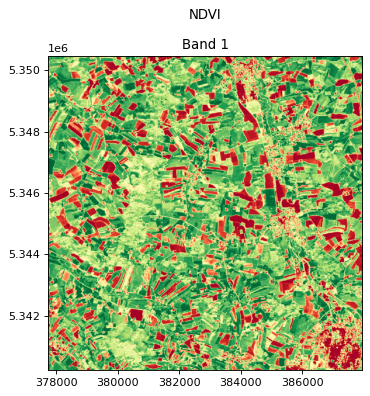

In [14]:
ndvi.plot_raster(cmap="RdYlGn", title="NDVI")

### NDWI

McFeeters' water index. On this farmland scene there is almost no surface water, so the mask is nearly empty - which is the honest result, and a good reminder to look at the histogram before trusting a threshold. A real flood is mapped in [../03_real_world/01_flood_mapping_ndwi](../03_real_world/01_flood_mapping_ndwi.ipynb).

ndwi range   : -0.862 to 0.224
ndwi > 0     : 349 pixels (0.033%)


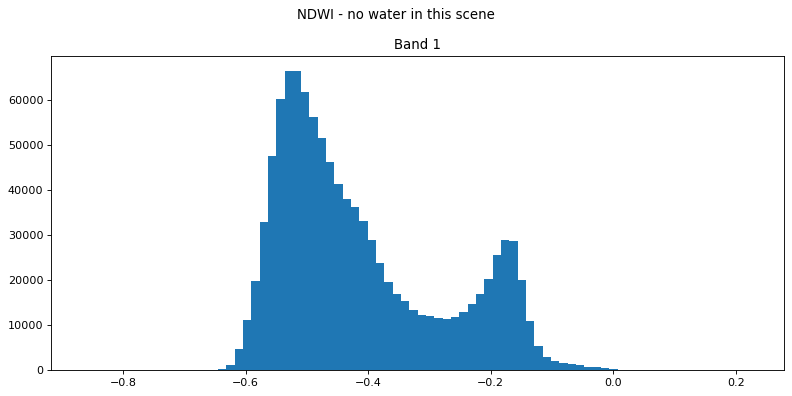

In [15]:
ndwi = scene.ndwi(nir="nir", green="green")
water = ndwi.get_band(1)

print(f"ndwi range   : {np.nanmin(water):.3f} to {np.nanmax(water):.3f}")
print(f"ndwi > 0     : {int((water > 0).sum()):,} pixels ({(water > 0).mean() * 100:.3f}%)")
ndwi.plot_histogram(bins=80, title="NDWI - no water in this scene")

### EVI

EVI is the one index whose formula is **not** scale-invariant: its constants assume reflectance in roughly `[0, 1]`. Feed it raw digital numbers and the result is nonsense - so divide first.

In [16]:
evi_wrong = scene.evi(red="red", blue="blue", nir="nir")
evi_right = scene.divide(10000).evi(red="red", blue="blue", nir="nir")

print(f"raw DN        : {float(np.nanmean(evi_wrong.get_band(1))):10.4f}   <- meaningless")
print(f"reflectance   : {float(np.nanmean(evi_right.get_band(1))):10.4f}   <- plausible (EVI is ~ -1 to 1)")
evi_wrong.close()

raw DN        :     2.1767   <- meaningless
reflectance   :     0.5200   <- plausible (EVI is ~ -1 to 1)


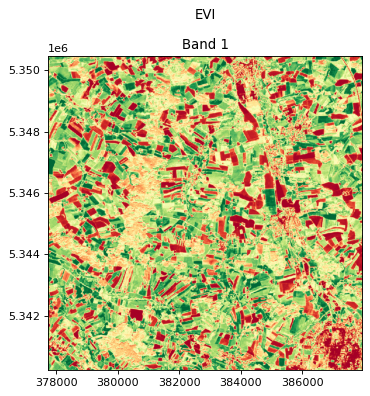

In [17]:
evi_right.plot_raster(cmap="RdYlGn", title="EVI")

## Dtype and nodata rules

Two rules hold for every index and every algebra operation:

1. Output is **float32**, whatever went in.
2. Nodata is **contagious** - a pixel that is nodata in any input band is `NaN` in the output, and the result declares `nodata=nan`.

Clipping to the ROI introduces genuine nodata, which makes the second rule visible.

In [18]:
import geopandas as gpd

roi = gpd.read_file(sd.boundary)
clipped = scene.clip_raster_with_vector(roi)
clipped_ndvi = clipped.ndvi(red="red", nir="nir")

result = clipped_ndvi.get_band(1)
print("dtype  :", clipped_ndvi.get_metadata()["dtype"])
print("nodata :", clipped_ndvi.get_metadata()["nodata"])
print(f"NaN    : {int(np.isnan(result).sum()):,} of {result.size:,} pixels "
      f"({np.isnan(result).mean() * 100:.1f}%) - the area outside the polygon")

dtype  : float32
nodata : nan
NaN    : 93,496 of 372,608 pixels (25.1%) - the area outside the polygon


An index result is deliberately **not** auto-named after the operation, because the library cannot know what you intend to call it. Name it yourself with `name=`.

In [19]:
print("unnamed:", ndvi.band_names)
named = scene.ndvi(red="red", nir="nir", name="ndvi")
print("named  :", named.band_names)

unnamed: [None]
named  : ['ndvi']


## Normalization

Three ways to rescale values, all returning float32.

- `normalize_min_max` - linear rescale to a range you choose
- `normalize_percentile` - clip to percentile bounds first, which is what makes satellite imagery readable (a few bright pixels otherwise dominate the range)
- `standardize` - z-score, `(x - mean) / std`

In [20]:
minmax = ndvi.normalize_min_max(new_min=0, new_max=1)
pct = ndvi.normalize_percentile(lower_percentile=2, upper_percentile=98)
zscore = ndvi.standardize()

for label, ds in (("min-max", minmax), ("percentile", pct), ("z-score", zscore)):
    a = ds.get_band(1)
    print(f"{label:11s} min {np.nanmin(a):7.3f}  max {np.nanmax(a):7.3f}  mean {np.nanmean(a):7.3f}")

min-max     min   0.000  max   1.000  mean   0.653
percentile  min   0.000  max   1.000  mean   0.611
z-score     min  -3.093  max   1.647  mean   0.000


`standardize` computes its mean and standard deviation over the **whole dataset**, not band by band - so on a multi-band raster the individual bands do not each end up with mean 0.

In [21]:
multiband = scene.standardize()

for name in multiband.band_names:
    a = multiband.get_band(name)
    print(f"{name:6s} mean {float(np.nanmean(a)):7.3f}  std {float(np.nanstd(a)):6.3f}")

whole = multiband.to_array()
print(f"\nwhole dataset: mean {float(np.nanmean(whole)):.3f}  std {float(np.nanstd(whole)):.3f}")

blue   mean  -0.630  std  0.323
green  mean  -0.390  std  0.387
red    mean  -0.472  std  0.510
nir    mean   1.493  std  0.696

whole dataset: mean 0.000  std 1.000


In [22]:
for ds in (scene, reflectance, same, red, nir, red_r, nir_r, wrapped, signed, coarse_red,
           aligned, difference, total, ratio, generic, by_name, by_index, by_dataset, ndvi,
           savi_0, savi_half, ndwi, evi_right, clipped, clipped_ndvi, named, minmax, pct,
           zscore, multiband):
    ds.close()
print("closed")

closed


## Next

- **[05_stacking_bands](05_stacking_bands.ipynb)** - build a multi-band scene from separate files
- **[../03_real_world/02_vegetation_health_and_drought](../03_real_world/02_vegetation_health_and_drought.ipynb)** - these indices on a real agricultural scene